## Load Dependencies

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter

# Download stopwords if not already downloaded
# nltk.download('stopwords')

## Load Data

#### Note: **make sure the encoding is set to latin1 not the default utf-8**

In [4]:
df=pd.read_csv("../data/spam.csv",encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df=df[["v1","v2"]]
df.rename(columns={"v1":"label","v2":"message"},inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


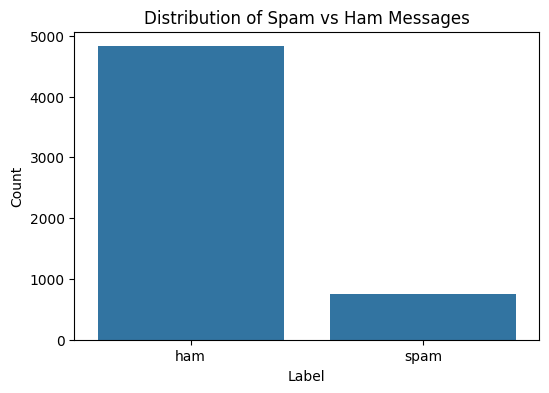

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Label')
plt.ylabel('Count')

plt.show()

## Preprocessing

In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
stopwords_set=set(stopwords.words("english"))

def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^0-9a-zA-Z]"," ",text)
    text=re.sub(r"\s+"," ",text)
    text=" ".join(word for word in text.split() if word not in stopwords_set)
    return text

In [9]:
df["cleaned_text"]=df["message"].apply(clean_text)
df["label"]=df["label"].map({"ham":0,"spam":1})
df.head()

,label,message,cleaned_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


## Splitting the Input

In [10]:
X=df["cleaned_text"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Architecture

In [22]:
class TextCNN(nn.Module):
    def __init__(self,vocab_size,embed_size,kernel_sizes,num_channels,dropout=0.7):
        super(TextCNN, self).__init__()
        self.embedding=nn.Embedding(vocab_size,embed_size,padding_idx=0)
        self.dropout=nn.Dropout(dropout)
        self.decoder=nn.Linear(sum(num_channels),2)
        self.pool=nn.AdaptiveMaxPool1d(1)
        self.relu=nn.ReLU()
        self.convs=nn.ModuleList([nn.Conv1d(embed_size,num_channels[i],kernel_size) for i,kernel_size in enumerate(kernel_sizes)])
        
    def forward(self, inputs):
        embeddings=self.embedding(inputs)
        embeddings=embeddings.permute(0,2,1)
        conv_outputs=[]
        for conv in self.convs:
            conv_out=conv(embeddings)
            conv_out=self.relu(conv_out)
            pooled=self.pool(conv_out)
            conv_outputs.append(pooled.squeeze(2))
        encoding=torch.cat(conv_outputs,dim=1)
        encoding=self.dropout(encoding)
        outputs=self.decoder(encoding)
        
        return outputs

## Model Training

In [23]:
from collections import Counter

def tokenize(text):
    return text.split()

counter=Counter()

for text in X_train:
    counter.update(tokenize(text))

vocab={word:i+1 for i,(word,_) in enumerate(counter.items())}
vocab["<pad>"]=0
vocab["<unk>"]=len(vocab)
vocab_size=len(vocab)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 7585


In [24]:
max_len=50

def encode(text):
    return [vocab.get(word,vocab["<unk>"]) for word in tokenize(text)]

def pad_sequence(seq):
    if len(seq)<max_len:
        return seq+[0]*(max_len-len(seq))
    return seq[:max_len]

X_train_seq=[pad_sequence(encode(text)) for text in X_train]
X_test_seq=[pad_sequence(encode(text)) for text in X_test]

X_train_tensor=torch.tensor(X_train_seq,dtype=torch.long)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.long)

X_test_tensor=torch.tensor(X_test_seq,dtype=torch.long)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.long)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")

Training data shape: torch.Size([4457, 50])
Test data shape: torch.Size([1115, 50])


In [25]:
embed_size=500
kernel_sizes=[3,4,5]
num_channels=[100,100,100]
learning_rate=0.001
num_epochs=5
batch_size=64

train_dataset=torch.utils.data.TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=torch.utils.data.TensorDataset(X_test_tensor,y_test_tensor)

train_loader=torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=torch.utils.data.DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

model=TextCNN(vocab_size,embed_size,kernel_sizes,num_channels)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [26]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=model.to(device)
print(f"Using device: {device}")

train_losses=[]
train_accuracies=[]
test_accuracies=[]

for epoch in range(num_epochs):
    model.train()
    total_loss=0
    correct=0
    total=0
    
    for batch_X,batch_y in train_loader:
        batch_X,batch_y=batch_X.to(device),batch_y.to(device)
        
        outputs=model(batch_X)
        loss=criterion(outputs,batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss+=loss.item()
        _, predicted=torch.max(outputs.data,1)
        total+=batch_y.size(0)
        correct+=(predicted==batch_y).sum().item()
    
    avg_loss=total_loss/len(train_loader)
    train_acc=100*correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    
    model.eval()
    correct=0
    total=0
    
    with torch.no_grad():
        for batch_X,batch_y in test_loader:
            batch_X,batch_y=batch_X.to(device),batch_y.to(device)
            outputs=model(batch_X)
            _,predicted=torch.max(outputs.data,1)
            total+=batch_y.size(0)
            correct+=(predicted==batch_y).sum().item()
    
    test_acc=100*correct/total
    test_accuracies.append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Test Acc: {test_acc:.2f}%")

Using device: cpu
Epoch [1/5]
Train Loss: 0.2980, Train Acc: 89.59%
Test Acc: 96.50%
Epoch [2/5]
Train Loss: 0.0749, Train Acc: 97.80%
Test Acc: 97.85%
Epoch [3/5]
Train Loss: 0.0406, Train Acc: 99.12%
Test Acc: 97.76%
Epoch [4/5]
Train Loss: 0.0264, Train Acc: 99.26%
Test Acc: 97.94%
Epoch [5/5]
Train Loss: 0.0230, Train Acc: 99.35%
Test Acc: 98.12%


## Training Visualization

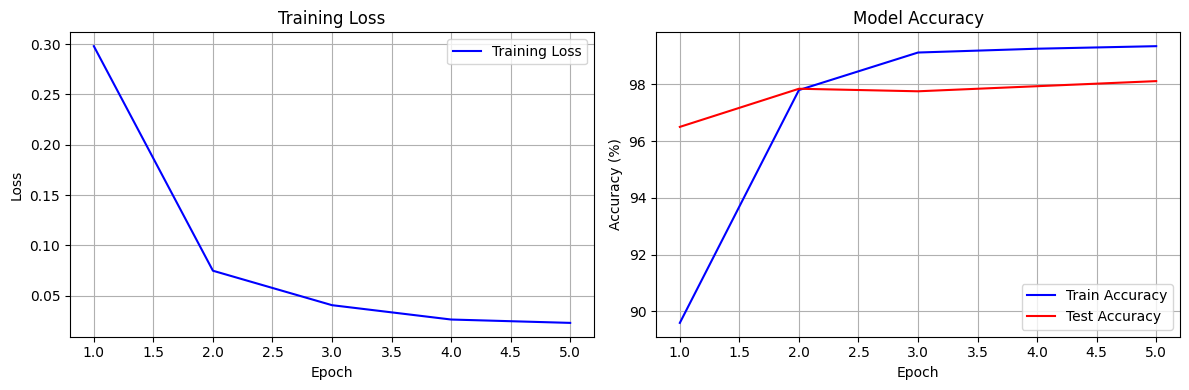

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), train_losses, 'b-', label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, num_epochs+1), train_accuracies, 'b-', label='Train Accuracy')
ax2.plot(range(1, num_epochs+1), test_accuracies, 'r-', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Model Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Model Evaluation

Final Test Accuracy: 98.12%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       965
        Spam       0.94      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



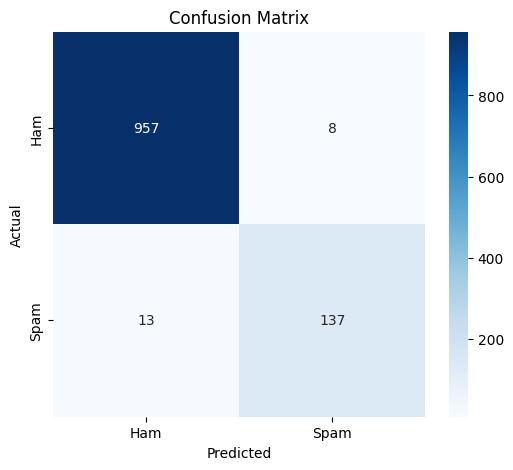

In [28]:
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
conf_matrix = confusion_matrix(all_labels, all_predictions)
class_report = classification_report(all_labels, all_predictions, target_names=['Ham', 'Spam'])

print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(class_report)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Testing with Custom Messages

In [29]:
def predict_message(message):
    cleaned=clean_text(message)
    encoded=encode(cleaned)
    padded=pad_sequence(encoded)
    
    tensor_input=torch.tensor([padded],dtype=torch.long).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs=model(tensor_input)
        _,predicted=torch.max(outputs,1)
        probabilities=F.softmax(outputs,dim=1)
    
    label="Spam" if predicted.item()==1 else "Ham"
    confidence=probabilities[0][predicted].item()*100
    
    return label,confidence

# Test with some examples
test_messages = [
    "Congratulations! You've won a free iPhone. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: http://fake-link.com",
    "Thanks for the movie recommendation, I really enjoyed it!",
    "FREE entry for a Disney holiday! Text WIN to 80085 now!",
    "Can you pick up some milk on your way home?"
]

print("Testing custom messages:")
print("-" * 60)
for msg in test_messages:
    label, confidence = predict_message(msg)
    print(f"Message: {msg}...")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

Testing custom messages:
------------------------------------------------------------
Message: Congratulations! You've won a free iPhone. Click here to claim now!...
Prediction: Spam (Confidence: 99.99%)

Message: Hey, are we still meeting for lunch tomorrow?...
Prediction: Ham (Confidence: 100.00%)

Message: URGENT: Your account has been compromised. Verify now: http://fake-link.com...
Prediction: Spam (Confidence: 99.96%)

Message: Thanks for the movie recommendation, I really enjoyed it!...
Prediction: Ham (Confidence: 98.89%)

Message: FREE entry for a Disney holiday! Text WIN to 80085 now!...
Prediction: Spam (Confidence: 99.97%)

Message: Can you pick up some milk on your way home?...
Prediction: Ham (Confidence: 100.00%)

